In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

# 1. Api z .env
load_dotenv()
api_key = os.getenv("COINGECKO_API_KEY")

# 2. URL Z API
url = "https://api.coingecko.com/api/v3/coins/markets"

# Parametry zapytania
params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,
    "page": 1,
    "sparkline": "false"
}

# Nagłówki
headers = {
    "accept": "application/json",
    "x-cg-demo-api-key": api_key
}

print("Pobieranie aktualnych danych rynkowych z CoinGecko API...")

# 3. Wysyłamy zapytanie do API
response = requests.get(url, params=params, headers=headers)

if response.status_code == 200:
    data = response.json()
    
    # 4. Wyciągnięcie kolumn
    crypto_data = []
    for coin in data:
        crypto_data.append({
            "Nazwa": coin["name"],
            "Symbol": coin["symbol"].upper(),
            "Cena (USD)": coin["current_price"],
            "Kapitalizacja rynkowa": coin["market_cap"],
            "Wolumen (24h)": coin["total_volume"],
            "Zmiana % (24h)": coin["price_change_percentage_24h"]
        })
        
    # 5. tabela Pandas
    df = pd.DataFrame(crypto_data)
    print(f"Sukces! Pobrano dane dla {len(df)} kryptowalut.")
else:
    print(f"Błąd połączenia z API: {response.status_code}")
    print(response.text)



Pobieranie aktualnych danych rynkowych z CoinGecko API...
Sukces! Pobrano dane dla 50 kryptowalut.


In [2]:
from datetime import datetime

current_time = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"crypto_data_{current_time}.csv"
df.to_csv(filename, index=False)
print(f" Dane zapisane do pliku: {filename}")

 Dane zapisane do pliku: crypto_data_20260625_2024.csv


1. TOP 5 KRYPTOWALUT O NAJWIĘKSZYM WZROŚCIE (24h)


,Nazwa,Symbol,Zmiana % (24h),Cena (USD)
18,LAB,LAB,14.91908,18.550000
9,Hyperliquid,HYPE,4.92749,63.320000
41,World Liberty Financial,WLFI,4.19597,0.059310
49,Ondo,ONDO,3.90622,0.310396
26,Bitcoin Cash,BCH,3.48020,189.860000



 2. PODSTAWOWE STATYSTYKI RYNKOWE


,Cena (USD),Zmiana % (24h)
count,50.000000,50.000000
mean,1422.718834,0.829544
std,8418.398880,2.605954
min,0.000002,-3.830380
25%,0.524889,-0.130500
50%,1.015000,0.133925
75%,46.327500,1.222683
max,59483.000000,14.919080



 3. ŁĄCZNA WARTOŚĆ TOP 50 PROJEKTÓW
Łączna kapitalizacja tych 50 projektów to: $2,045,475,663,700.00 USD


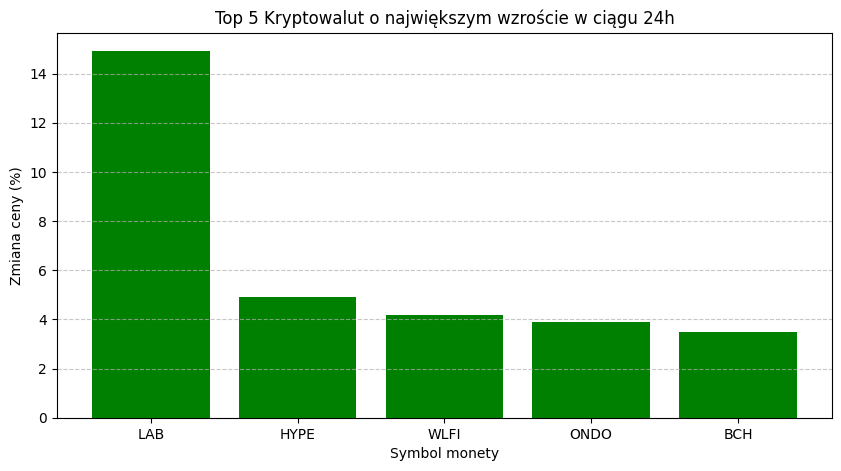

In [4]:
# Wyświetlamy 5 pierwszych wierszy tabeli
df.head()

print("1. TOP 5 KRYPTOWALUT O NAJWIĘKSZYM WZROŚCIE (24h)")
# Sortujemy tabelę po kolumnie ze zmianą procentową malejąco
top_gainers = df.sort_values(by="Zmiana % (24h)", ascending=False).head(5)
display(top_gainers[["Nazwa", "Symbol", "Zmiana % (24h)", "Cena (USD)"]])

print("\n 2. PODSTAWOWE STATYSTYKI RYNKOWE")

display(df[["Cena (USD)", "Zmiana % (24h)"]].describe())

print("\n 3. ŁĄCZNA WARTOŚĆ TOP 50 PROJEKTÓW")
total_market_cap = df["Kapitalizacja rynkowa"].sum()
print(f"Łączna kapitalizacja tych 50 projektów to: ${total_market_cap:,.2f} USD")
import matplotlib.pyplot as plt

# Pobieramy top 5 liderów wzrostów
top_gainers = df.sort_values(by="Zmiana % (24h)", ascending=False).head(5)

# Tworzymy wykres słupkowy
plt.figure(figsize=(10, 5))
plt.bar(top_gainers["Symbol"], top_gainers["Zmiana % (24h)"], color="green")

# Dodajemy tytuły i etykiety
plt.title("Top 5 Kryptowalut o największym wzroście w ciągu 24h")
plt.xlabel("Symbol monety")
plt.ylabel("Zmiana ceny (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Wyświetlamy wykres bezpośrednio w notebooku
plt.show()